In [65]:
import numpy as np
import matplotlib.pyplot as plt

from astropy.io import fits
from astropy.table import Table

from scipy import ndimage
from scipy.optimize import curve_fit

import astroalign as aa
from scipy.spatial import cKDTree

In [66]:
campo = fits.open('./M41.fits')

In [67]:
campo.info()

Filename: ./M41.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      35   (3096, 2080)   float64   
  1                1 ImageHDU        36   (3096, 2080)   float64   
  2                1 ImageHDU        36   (3096, 2080)   float64   


In [68]:
campo[0].header

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                  -64 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                 3096                                                  
NAXIS2  =                 2080                                                  
EXTEND  =                    T                                                  
DATE-OBS= '2026-02-14T03:25:11.255' / UTC start date of observation             
EXPTIME =                   5. / Total Exposure Time (s)                        
EXPOINUS=              5000000 / Exposure time in us                            
INSTRUME= 'ZWO ASI178MM'       / Camera model                                   
SWCREATE= 'ASIImg  '           / Name of software that created the image        
SWOWNER = 'ZWO     '           / Licensed owner of software                     
XPIXSZ  =                  2

In [69]:
campo[1].header

XTENSION= 'IMAGE   '           / Image extension                                
BITPIX  =                  -64 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                 3096                                                  
NAXIS2  =                 2080                                                  
PCOUNT  =                    0 / number of parameters                           
GCOUNT  =                    1 / number of groups                               
DATE-OBS= '2026-02-14T03:28:41.128' / UTC start date of observation             
EXPTIME =                   5. / Total Exposure Time (s)                        
EXPOINUS=              5000000 / Exposure time in us                            
INSTRUME= 'ZWO ASI178MM'       / Camera model                                   
SWCREATE= 'ASIImg  '           / Name of software that created the image        
SWOWNER = 'ZWO     '        

In [70]:
campo[2].header

XTENSION= 'IMAGE   '           / Image extension                                
BITPIX  =                  -64 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                 3096                                                  
NAXIS2  =                 2080                                                  
PCOUNT  =                    0 / number of parameters                           
GCOUNT  =                    1 / number of groups                               
DATE-OBS= '2026-02-14T03:32:22.892' / UTC start date of observation             
EXPTIME =                   5. / Total Exposure Time (s)                        
EXPOINUS=              5000000 / Exposure time in us                            
INSTRUME= 'ZWO ASI178MM'       / Camera model                                   
SWCREATE= 'ASIImg  '           / Name of software that created the image        
SWOWNER = 'ZWO     '        

In [71]:
blue = np.array(campo[0].data, dtype=np.float64)
green = np.array(campo[1].data, dtype=np.float64)
red = np.array(campo[2].data, dtype=np.float64)

Las imágenes adquiridas en los filtros blue, green y red presentan un desfase en la declinación, atribuible a imprecisiones en el sistema de tracking del telescopio durante la observación.

En consecuencia, antes de proceder con el procesamiento fotométrico, se realizó una corrección geométrica consistente en la rotación y alineación de las imágenes. Esto permitió que las posiciones estelares coincidieran espacialmente entre los tres filtros, garantizando la correspondencia adecuada de las fuentes detectadas en cada imagen.

Detecta estrellas automáticamente

Encuentra rotación + traslación + escala

Aplica transformación

In [72]:
blue_aligned, _ = aa.register(blue, green)
red_aligned, _ = aa.register(red, green)

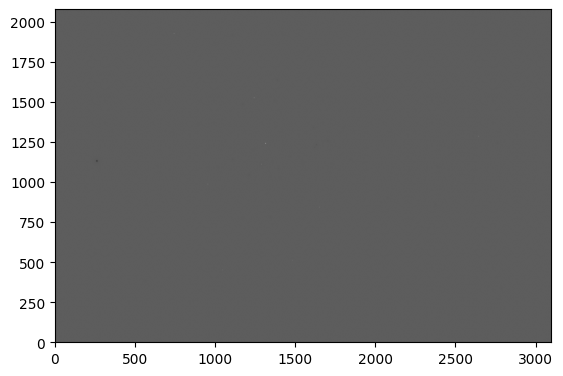

In [73]:
plt.imshow(green - blue_aligned, cmap='gray', origin='lower')

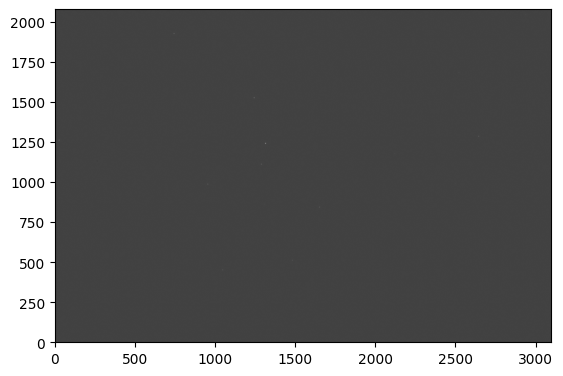

In [74]:
plt.imshow(green - red_aligned, cmap='gray', origin='lower')

### Fotometria de apertura

In [75]:
def dividir_grilla_maximos(image, nrows=5, ncols=6):
    h, w = image.shape
    dh = h // nrows
    dw = w // ncols
    
    centros = []
    
    for i in range(nrows):
        for j in range(ncols):
            #Extraemos la sub-region de la imagen
            sub = image[i*dh:(i+1)*dh, j*dw:(j+1)*dw]
            
            # posición del máximo local
            local_max = np.unravel_index(np.argmax(sub), sub.shape)
            
            y = i*dh + local_max[0]
            x = j*dw + local_max[1]
            
            centros.append((y, x))
    
    return np.array(centros)

In [76]:
def perfil_radial(image, y0, x0, rmax=15):
    #Extraemos los indices (posicion) de cada pixel
    y, x = np.indices(image.shape)
    #Calculamos la distancia entre cada punto de la imagen y el punto de interes (cada una de nuestras 30 estrellas mas brillantes)
    r = np.sqrt((x - x0)**2 + (y - y0)**2)
    r = r.astype(int)
    
    perfil = [] #Aqui guardaremos el valor promedio de intensidad en funcion de la distancia r
    radios = np.arange(0, rmax) #Establecemos la region alrededor de cada punto de interes a la cual extraeremos el perfil
    
    for r_val in radios:
        mask = (r == r_val) #Seleccionamos los pixeles dentro de la region seleccionada, que se encuentran a un radio r del centro
        if np.sum(mask) > 0: #Nos aseguramos de que tiene pixeles vecinos
            perfil.append(np.mean(image[mask]))
        else:
            perfil.append(0)
    
    return radios, np.array(perfil) #Devuelve la distancia r y su valor de intensidad, alrededor del punto de interes. 

In [77]:
def gauss(r, A, sigma, offset):
    return A * np.exp(-(r**2)/(2*sigma**2)) + offset

In [78]:
def calcular_fwhm(radios, perfil):
    A0 = np.max(perfil)
    sigma0 = 2 #Estimacion de la desviacion estandar de la distribucion
    offset0 = np.min(perfil)
    
    try:
        popt, _ = curve_fit(gauss, radios, perfil, p0=[A0, sigma0, offset0])
        sigma = popt[1]
        FWHM = 2.355 * sigma
        return FWHM
    except:
        return None

In [79]:
#Aqui vamos a extraer los perfiles radiales de las estrellas mas brillantes, luego calcular los 30 FWHM, y finalmente 
#promediarlos para estimar el FWHM de la imagen

def fwhm_imagen(image, centros):
    fwhms = []
    
    for (y,x) in centros:
        radios, perfil = perfil_radial(image, y, x)
        fwhm = calcular_fwhm(radios, perfil)
        if fwhm is not None:
            fwhms.append(fwhm)
    
    return np.mean(fwhms) #Con esta cantidad de estimaran los radios r1, r2, r3

In [113]:
def detectar_estrellas(image):
    threshold = np.mean(image) + 3*np.std(image) #Estimamos el ruido de fondo de la imagen
    
    max_filt = ndimage.maximum_filter(image, size=5) #Busca los maximos en ventanas de 5x5
    peaks = (image == max_filt)
    peaks &= (image > threshold) #El threshold se utiliza para descartar maximos de brillo menos brillantes que el ruido de fondo
    
    posiciones = np.argwhere(peaks)
    return posiciones

In [81]:
#Una vez conocemos la posicion de una estrella (x0, y0), aplicamos fotometria de apertura. Para este punto ya conocemos
#los radios r1, r2, r3 como constantes de la imagen.
def fotometria_apertura(image, y0, x0, r1, r2, r3):
    y, x = np.indices(image.shape)
    r = np.sqrt((x - x0)**2 + (y - y0)**2)
    
    # Apertura
    mask_ap = (r <= r1)
    suma_ap = np.sum(image[mask_ap]) #Intensidad total dentro de la apertura
    n_ap = np.sum(mask_ap) #Numero de pixeles dentro de la apertura
    
    # Sky annulus
    mask_sky = (r >= r2) & (r <= r3) #region de cielo
    suma_sky = np.sum(image[mask_sky]) #IIntensidad total dentro de la region de cielo
    n_sky = np.sum(mask_sky) #Numero de pixeles dentro de la region de cielo
    
    if n_sky == 0:
        return None
    
    densidad_cielo = suma_sky / n_sky #Densidad de cielo para la correccion de la intensidad de la estrella
    correccion = n_ap * densidad_cielo
    
    intensidad_verdadera = suma_ap - correccion
    
    return intensidad_verdadera #Devuelve la intensidad corregida de cada una de las estrellas de la imagen.

In [114]:
# Asociamos nombre a cada imagen
images = {
    "blue": blue_aligned,
    "green": green,
    "red": red_aligned
}

resultados = {}

for nombre_filtro, image in images.items():

    # 30 centros mas brillantes para estimar FWHM
    centros_grid = dividir_grilla_maximos(image)

    # FWHM promedio
    FWHM = fwhm_imagen(image, centros_grid)

    print(f"FWHM estimado para {nombre_filtro}: {FWHM:.2f} pixeles")

    # Radios para fotometria de apertura
    r1 = 3 * FWHM
    r2 = 4 * FWHM
    r3 = 5 * FWHM

    # Detectar estrellas reales
    estrellas = detectar_estrellas(image)

    datos = []

    for (y,x) in estrellas:
        I = fotometria_apertura(image, y, x, r1, r2, r3)

        if I and I > 0:
            m = -2.5 * np.log10(I / 25)
            datos.append((y, x, m))

    resultados[nombre_filtro] = np.array(datos)

FWHM estimado para blue: 2.84 pixeles
FWHM estimado para green: 2.58 pixeles
FWHM estimado para red: 2.66 pixeles


Hacer crossmatch geométrico

Quedarse solo con estrellas comunes

In [116]:
blue_cat = resultados["blue"][:, :2]
green_cat = resultados["green"][:, :2]
red_cat = resultados["red"][:, :2]

tree_green = cKDTree(green_cat)
tree_red = cKDTree(red_cat)

dist_g, idx_g = tree_green.query(blue_cat)
dist_r, idx_r = tree_red.query(blue_cat)

mask = (dist_g < 2) & (dist_r < 2)

matched_blue  = resultados["blue"][mask]
matched_green = resultados["green"][idx_g[mask]]
matched_red   = resultados["red"][idx_r[mask]]

In [117]:
len(matched_blue)

149

In [118]:
len(matched_green)

149

In [119]:
len(matched_red)

149

### Estructura del Cumulo

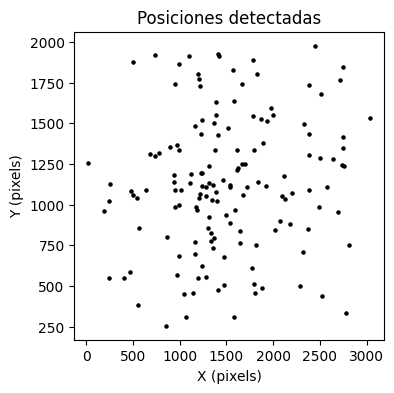

In [120]:
y = matched_blue[:,0]
x = matched_blue[:,1]

plt.figure(figsize=(4,4))
plt.scatter(x, y, s=5, color='black')

plt.xlabel("X (pixels)")
plt.ylabel("Y (pixels)")
plt.title("Posiciones detectadas")

plt.show()

### Diagrama Color - Magnitud

In [121]:
m_b = matched_blue[:,2]
m_g = matched_green[:,2]
m_r = matched_red[:,2]

color_1 = m_b - m_r
color_2 = m_g - m_r
color_3 = m_b - m_g


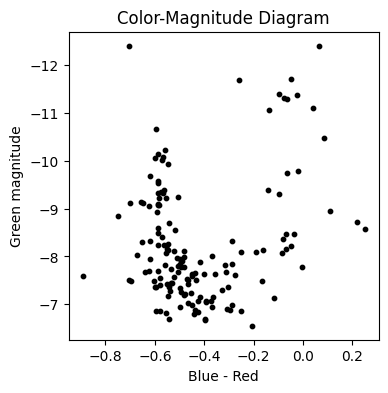

In [122]:
plt.figure(figsize=(4,4))
plt.scatter(color_1, m_g, s=10, color='black')

plt.gca().invert_yaxis()   # Magnitudes hacia abajo
plt.xlabel("Blue - Red")
plt.ylabel("Green magnitude")

plt.title("Color-Magnitude Diagram")
plt.show()

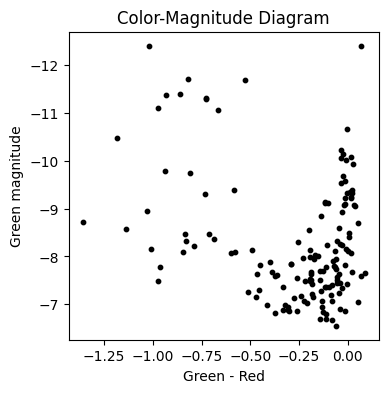

In [123]:
plt.figure(figsize=(4,4))
plt.scatter(color_2, m_g, s=10, color='black')

plt.gca().invert_yaxis()   # Magnitudes hacia abajo
plt.xlabel("Green - Red")
plt.ylabel("Green magnitude")

plt.title("Color-Magnitude Diagram")
plt.show()

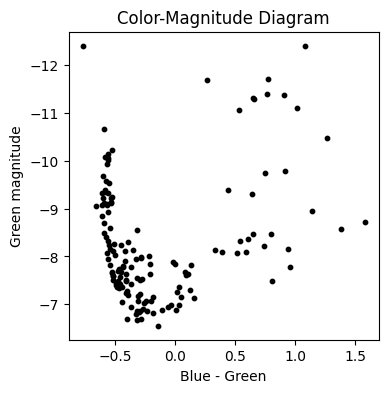

In [124]:
plt.figure(figsize=(4,4))
plt.scatter(color_3, m_g, s=10, color='black')

plt.gca().invert_yaxis()   # Magnitudes hacia abajo
plt.xlabel("Blue - Green")
plt.ylabel("Green magnitude")

plt.title("Color-Magnitude Diagram")
plt.show()

### Perfil radial

In [125]:
#Calculamos el centro del cumulo, como el valor promedio de posiciones
y_c = np.mean(y)
x_c = np.mean(x)

print("Centro del cúmulo (pixeles):")
print("y_c =", y_c)
print("x_c =", x_c)

Centro del cúmulo (pixeles):
y_c = 1127.8657718120805
x_c = 1509.8590604026845


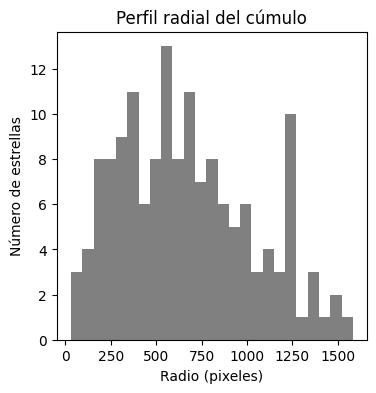

In [126]:
#Calculamos la distancia entre la posicion de cada elemento y el centro del cumulo
r = np.sqrt((x - x_c)**2 + (y - y_c)**2)

plt.figure(figsize=(4,4))
plt.hist(r, bins=25, color='Grey')

plt.xlabel("Radio (pixeles)")
plt.ylabel("Número de estrellas")
plt.title("Perfil radial del cúmulo")
plt.show()